In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Daily Household Transactions.csv')
df.head()


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [2]:
# Basic info
print(df.shape)
df.info()
print(df.isnull().sum())

# Convert 'Date' column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['Subcategory'].fillna('Unknown', inplace=True)
df['Note'].fillna('No Description', inplace=True)

# Check again
df.isnull().sum()


(2461, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB
Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64


C:\Users\yash\AppData\Local\Temp\ipykernel_19804\4106536505.py:7: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
C:\Users\yash\AppData\Local\Temp\ipykernel_19804\4106536505.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Subcategory'].fillna('Unknown', inplace=True)
C:\Users\yash\AppData\Local\Temp\ipykernel_19804\4106536505.py:14: FutureW

Date              754
Mode                0
Category            0
Subcategory         0
Note                0
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [3]:
df.describe()


,Date,Amount
count,1303,2057.000000
mean,2017-05-12 20:41:38.546431232,2791.281176
min,2015-01-13 18:52:47,2.000000
25%,2016-12-18 20:18:45.500000,30.000000
50%,2017-07-27 20:05:23,80.000000
75%,2018-01-30 12:09:30.500000,330.000000
max,2018-09-20 12:04:08,250000.000000
std,NaN,13598.659347


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Food'),
  Text(1, 0, 'Transportation'),
  Text(2, 0, 'Household'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'subscription'),
  Text(5, 0, 'Health'),
  Text(6, 0, 'Family'),
  Text(7, 0, 'Apparel'),
  Text(8, 0, 'Salary'),
  Text(9, 0, 'Gift')])

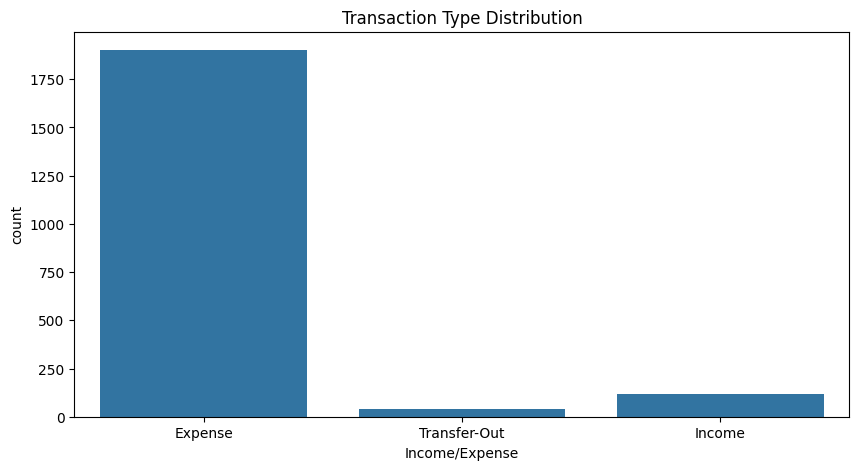

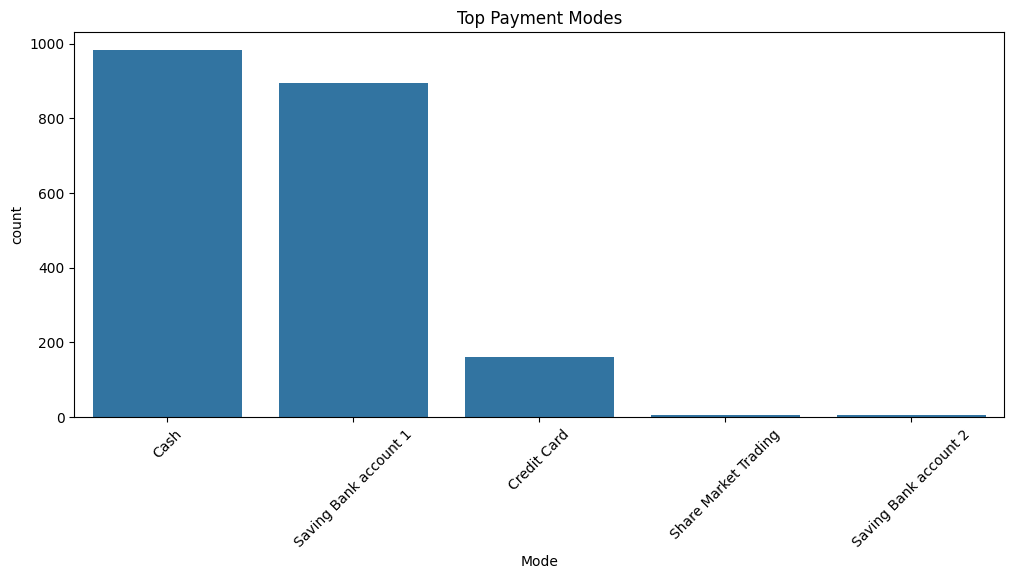

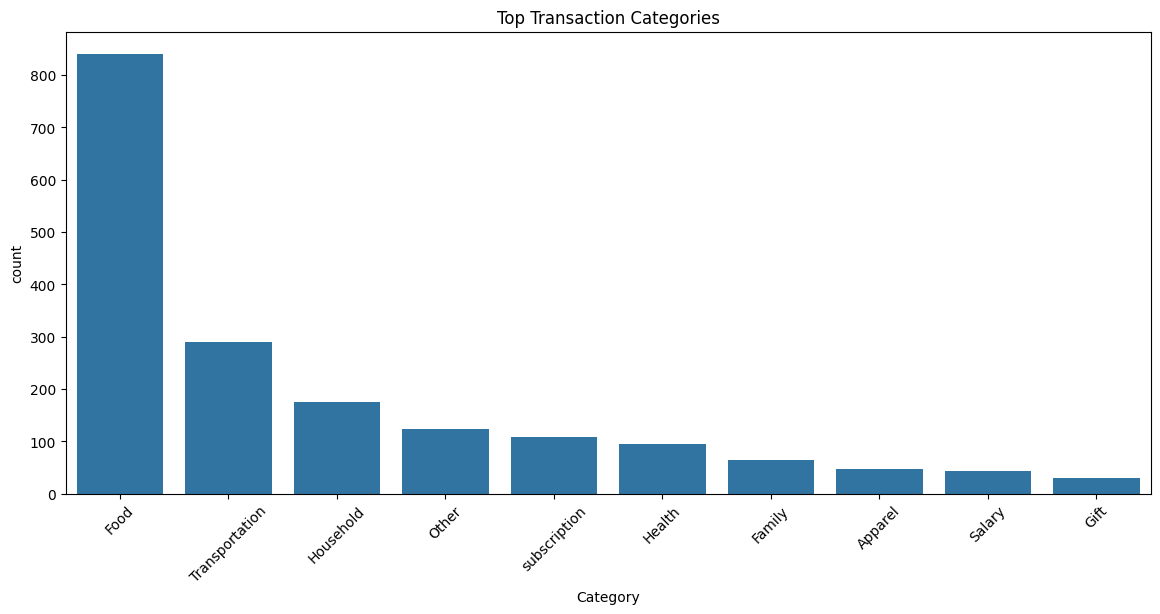

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Income/Expense')
plt.title('Transaction Type Distribution')

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Mode', order=df['Mode'].value_counts().iloc[:5].index)
plt.title('Top Payment Modes')
plt.xticks(rotation=45)

plt.figure(figsize=(14,6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().iloc[:10].index)
plt.title('Top Transaction Categories')
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Distribution of Transaction Amounts')

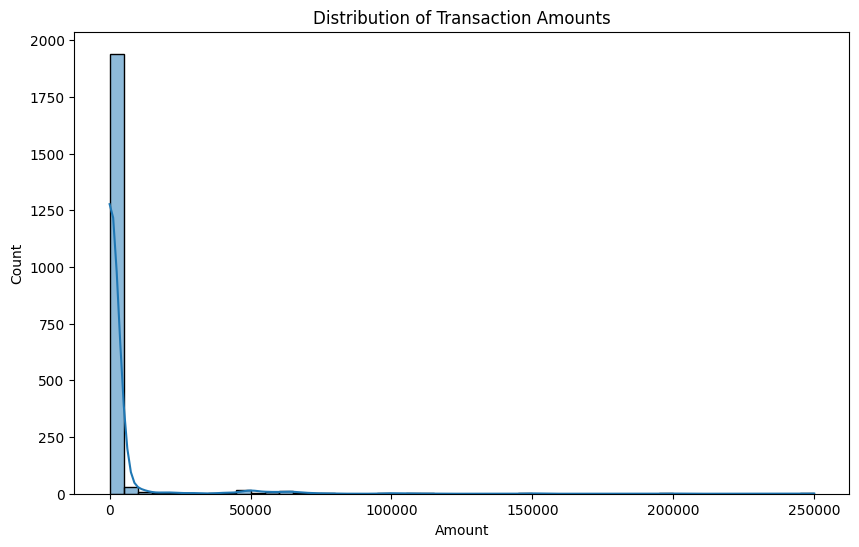

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')


C:\Users\yash\AppData\Local\Temp\ipykernel_19804\2455127286.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M', on='Date')['Amount'].sum()


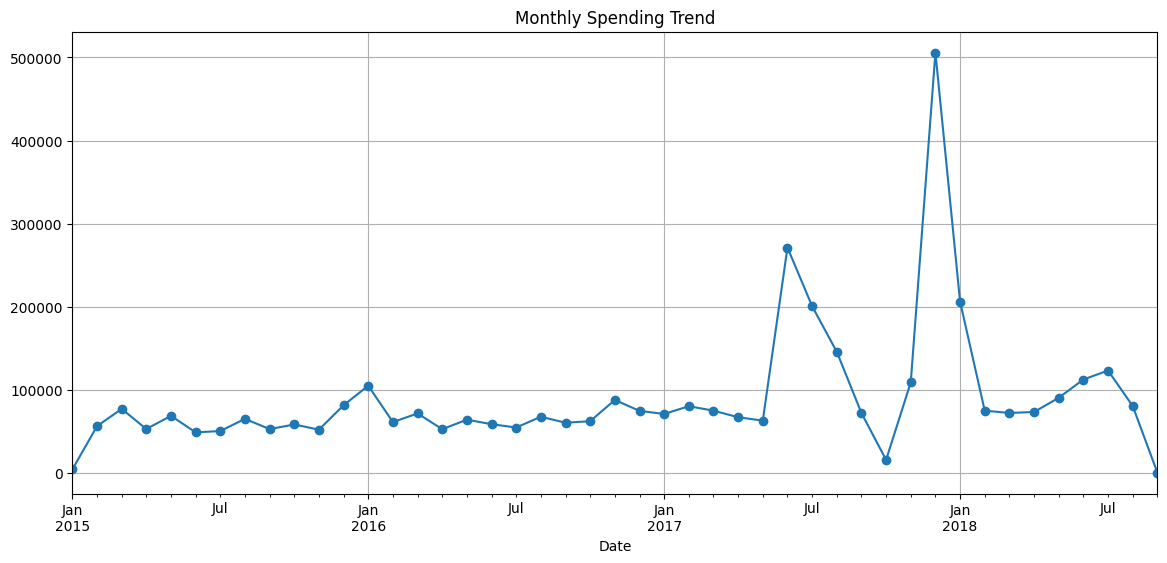

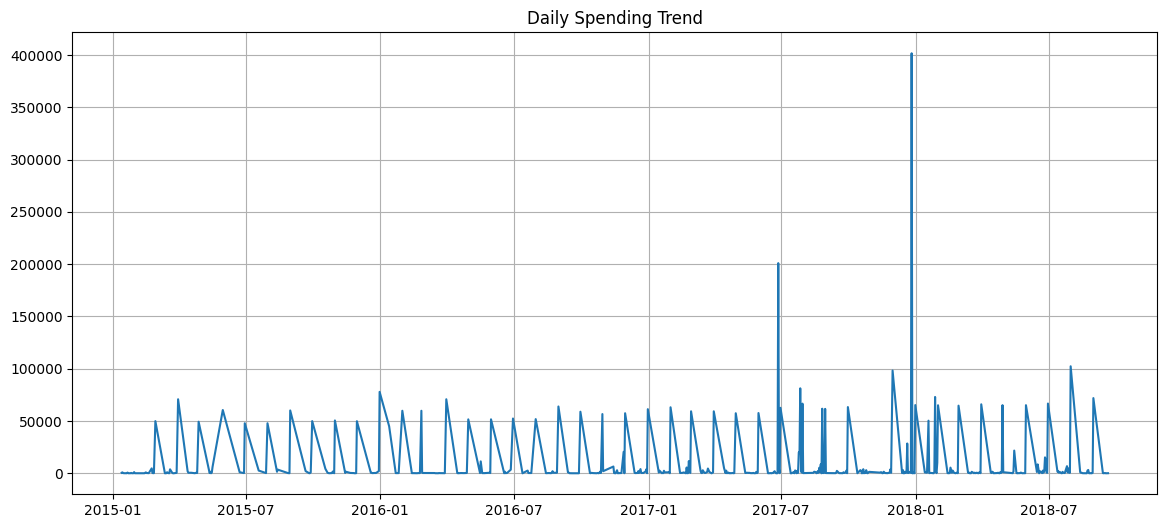

In [6]:
# Monthly trend
monthly = df.resample('M', on='Date')['Amount'].sum()
plt.figure(figsize=(14,6))
monthly.plot(marker='o')
plt.title('Monthly Spending Trend')
plt.grid(True)

# Daily trend
daily = df.groupby(df['Date'].dt.date)['Amount'].sum()
plt.figure(figsize=(14,6))
plt.plot(daily.index, daily.values)
plt.title('Daily Spending Trend')
plt.grid(True)


Text(0.5, 1.0, 'Correlation Between Categories')

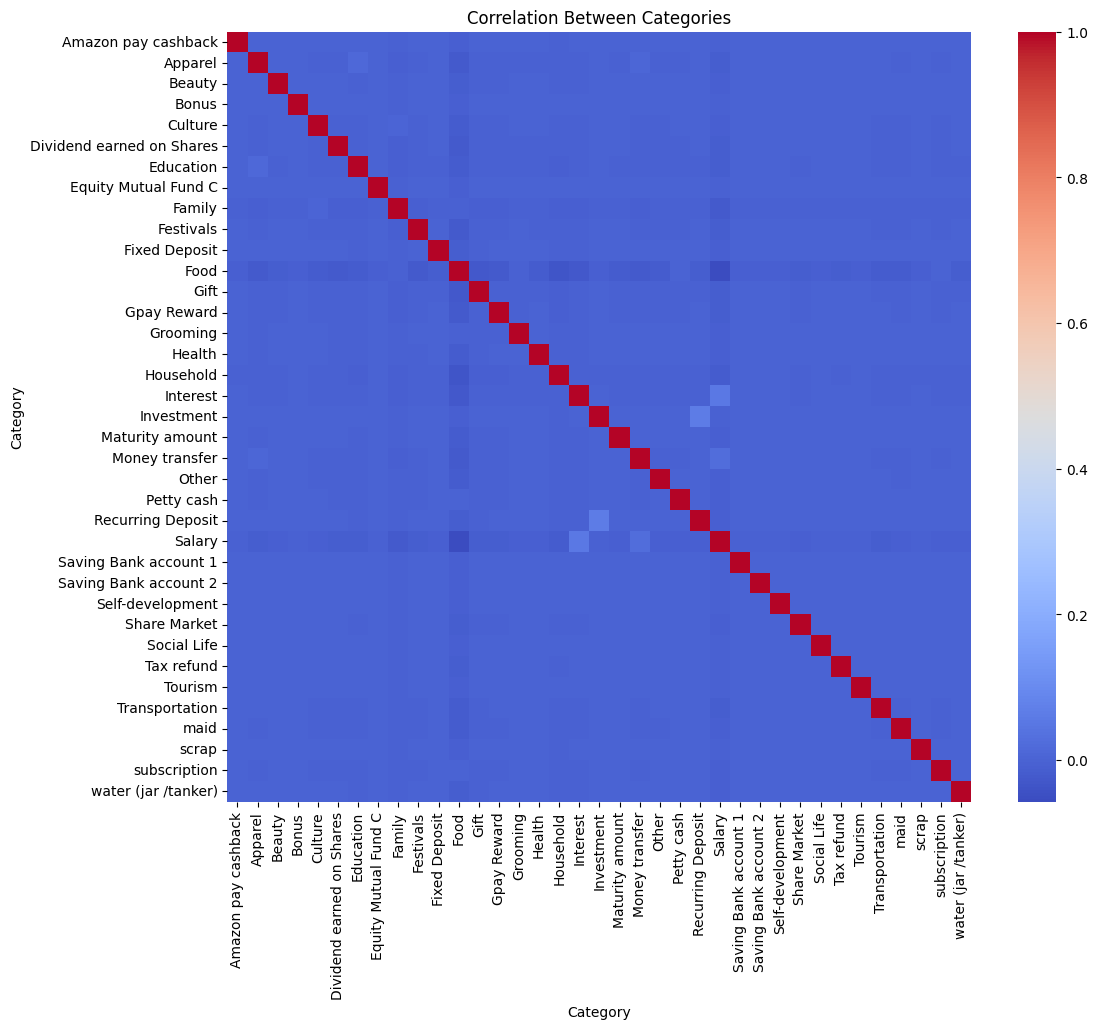

In [7]:
pivot = df.pivot_table(index='Date', columns='Category', values='Amount', aggfunc='sum', fill_value=0)
corr_matrix = pivot.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Between Categories')


In [8]:
df.to_csv('Cleaned_Daily_Transactions.csv', index=False)
